<center>

# **Import Data**

In [7]:
from datasets import load_dataset

ds = load_dataset("dair-ai/emotion", "split")

Using the latest cached version of the dataset since dair-ai/emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\ZBook\.cache\huggingface\datasets\dair-ai___emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Fri May 29 00:14:35 2026).


In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
ds["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [8]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

df = ds["train"].to_pandas()
df_val = ds["validation"].to_pandas()
df_test = ds["test"].to_pandas()


df.sample(10)

,text,label
5415,i do know im feeling times more guilty,0
7040,i smiled feeling my grandmothers presence in her sweet british accent,2
8831,i feel rejected by all the men i like i gave up on asking why and what i did so they ran away,0
6739,i remember in particular one new years day in high school when i was feeling all tragic and melancholy and generally fifteen year old girl ish,0
10495,i finally feel like im getting treatment for my injury and that im not being punished for having been injured during an assault,0
9305,i am feeling reassured by this a wave of missing hits,1
13348,i devised myself rather than had suggested to me the flower distribution and im esp pleased as i bought the flowers when i didnt have my bank card it feels much harder to be generous when having to be especially careful with money and im now wondering if that was the lesson of losing it,2
8918,i seriously feel talented now,1
10381,i feel like as a generation of men as a family guy in my s in the suburbs of the midwest i feel like were a little bit lost says heimbuch who documented a search for his midwestern hunting roots in his soon to be released book and now we shall do manly things,0
6430,i feel that everyone is entitiled to their opinion and that opinion should be respected,1


In [6]:
# number of unique classes
num_classes = df["label"].nunique()

print("Number of classes:", num_classes)

print("=" * 50)

# count samples in each class
class_counts = df["label"].value_counts()

print(class_counts)

Number of classes: 6
label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


 **sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5).**

In [7]:
# number of unique classes
num_classes_test = df_test["label"].nunique()

print("Number of classes:", num_classes_test)

print("=" * 50)

# count samples in each class
class_counts_test = df_test["label"].value_counts()

print(class_counts_test)

Number of classes: 6
label
1    695
0    581
3    275
4    224
2    159
5     66
Name: count, dtype: int64


<center>

# **Preprocessing**

In [1]:
import re
import string
import emoji

class EmotionPreprocessor:

    def __init__(self):

        self.punctuations = string.punctuation

        # dictionary mapping emojis >> emotion tokens
        self.emoji_map = {
            "😀": "joy_emoji", "😂": "joy_emoji", "🤣": "joy_emoji", "😆": "joy_emoji", "😁": "joy_emoji",
            "😥": "sadness_emoji", "☹": "sadness_emoji",
            "😡": "anger_emoji", "🤬": "anger_emoji",
            "😱": "fear_emoji", "😰": "fear_emoji", "😨": "fear_emoji",
            "😯": "surprise_emoji",
            "😍": "love_emoji", "😘": "love_emoji", "🥰": "love_emoji"}


    def normalize_emojis(self, text):

        # Convert any Unicode sequence or alias to the standard emoji
        return emoji.emojize(emoji.demojize(text), language='en')


    def replace_emojis(self, text):
        # replace mapped emojis with tokens
        for emo, token in self.emoji_map.items():
            text = text.replace(emo, f" {token} ")
        # remove any other emojis not in the map
        text = emoji.replace_emoji(text, replace='')
        return text
    

    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)   # remove links
        text = re.sub(r'\d+', '', text)              # remove numbers
        text = self.normalize_emojis(text)           # normalize emojis
        text = self.replace_emojis(text)             # handle emojis
        text = text.translate(str.maketrans('', '', self.punctuations)) # remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
        return text


In [9]:
prep = EmotionPreprocessor()

text = "I am soooo happy 😂😂❤️ but yesterday I was sad 😥"

cleaned = prep.clean_text(text)

print("Original:")
print(text)

print("\nCleaned:")
print(cleaned)

Original:
I am soooo happy 😂😂❤️ but yesterday I was sad 😥

Cleaned:
i am soooo happy joyemoji joyemoji but yesterday i was sad sadnessemoji


In [10]:
prep = EmotionPreprocessor()

text = "I am happy \U0001F602 and love you \U00002764"

print(text)
print(prep.clean_text(text))

I am happy 😂 and love you ❤
i am happy joyemoji and love you


In [12]:
prep = EmotionPreprocessor()

df["clean_text"] = df["text"].apply(prep.clean_text)
df_val["clean_text"] = df_val["text"].apply(prep.clean_text)
df_test["clean_text"] = df_test["text"].apply(prep.clean_text)



In [14]:
df.sample(10)

,text,label,clean_text
1021,i feel like as much as it was an unfortunate situation that i wasnt with my father i was in a great place,0,i feel like as much as it was an unfortunate situation that i wasnt with my father i was in a great place
11160,im blocked i could at least be doing something constructive my room needs a major cleaning for instance but i feel agitated if im not at least doing research for this story it does require a lot of research,3,im blocked i could at least be doing something constructive my room needs a major cleaning for instance but i feel agitated if im not at least doing research for this story it does require a lot of research
6237,i feel sooo bitchy that i made out with devin,3,i feel sooo bitchy that i made out with devin
8430,i mean architectural wonders just make you feel wowed impressed and you just end up really respecting the people who built them but nature just makes you feel so much more aware of the world around you without actually actively doing anything because they were always there you know,5,i mean architectural wonders just make you feel wowed impressed and you just end up really respecting the people who built them but nature just makes you feel so much more aware of the world around you without actually actively doing anything because they were always there you know
607,i admire athleticism i feel like i would be more entertained if i got to watch severely out of shape people participate in olympic events,1,i admire athleticism i feel like i would be more entertained if i got to watch severely out of shape people participate in olympic events
1422,i hate all shopping when i feel rushed by hoards of people,3,i hate all shopping when i feel rushed by hoards of people
13017,i feel obama is simply because hillary is so hated by so many,0,i feel obama is simply because hillary is so hated by so many
15340,i really hope im the only blogger they have treat this badly as i still feel super lousy about all and i wouldnt wish this crap on my worst enemy,1,i really hope im the only blogger they have treat this badly as i still feel super lousy about all and i wouldnt wish this crap on my worst enemy
13517,i was really worried that i would feel intimidated by monica but when we met that morning she was incredibly welcoming and made me feel relaxed straight away,4,i was really worried that i would feel intimidated by monica but when we met that morning she was incredibly welcoming and made me feel relaxed straight away
4587,i breaking skin feels like and it s not pleasant,1,i breaking skin feels like and it s not pleasant


<center>

# **Tokenization**

In [2]:
from transformers import DistilBertTokenizerFast

class EmotionTokenizer:
    def __init__(self, model_name="distilbert-base-uncased", max_length=128):
        self.tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
        self.max_length = max_length

    def tokenize(self, texts):
        return self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"  # PyTorch tensors
        )


In [16]:
tok = EmotionTokenizer()

# Tokenize
train_encodings = tok.tokenize(df["clean_text"].tolist())
val_encodings   = tok.tokenize(df_val["clean_text"].tolist())
test_encodings  = tok.tokenize(df_test["clean_text"].tolist())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\ZBook\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ZBook\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

<center>

# **Transformer**

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0,1,2,3,4,5])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=df["label"])
class_weights_dict = {cls: w for cls, w in zip(classes, class_weights)}

print("Class Weights:", class_weights_dict)


Class Weights: {0: 0.5715102157451064, 1: 0.49732686808404825, 2: 2.044989775051125, 3: 1.2351397251814111, 4: 1.3766993632765445, 5: 4.662004662004662}


In [11]:
class_weights=np.array([0.57151022, 0.49732687, 2.04498978, 1.23513973, 1.37669936,4.66200466])
class_weights

array([0.57151022, 0.49732687, 2.04498978, 1.23513973, 1.37669936,
       4.66200466])

### **Class for classify Emotion**

In [4]:
import torch
import torch.nn as nn
from transformers import DistilBertModel

class EmotionClassifier(nn.Module):
    def __init__(self, num_classes=6, class_weights=None, threshold=0.6):
        super(EmotionClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
        
        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float))
        else:
            self.loss_fn = nn.CrossEntropyLoss()
        
        self.threshold = threshold
        self.label_map = {
            0: "sadness",
            1: "joy",
            2: "love",
            3: "anger",
            4: "fear",
            5: "surprise"
        }

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:,0]  # CLS token
        pooled_output = self.dropout(pooled_output)
        logits = self.fc(pooled_output)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return logits, loss

    def predict(self, input_ids, attention_mask):
        self.eval()
        with torch.no_grad():
            logits, _ = self.forward(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)
            max_probs, preds = torch.max(probs, dim=1)

            results = []
            for prob, pred in zip(max_probs, preds):
                if prob < self.threshold:
                    results.append("normal")
                else:
                    results.append(self.label_map[int(pred)])
            return results


### **Training & Evaluation**

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AdamW
from tqdm import tqdm
from tqdm import tqdm

def train_model(model, train_encodings, train_labels, val_encodings, val_labels, epochs=5, batch_size=32, lr=5e-5):
    train_dataset = TensorDataset(
        train_encodings["input_ids"], 
        train_encodings["attention_mask"], 
        torch.tensor(train_labels)
    )
    val_dataset = TensorDataset(
        val_encodings["input_ids"], 
        val_encodings["attention_mask"], 
        torch.tensor(val_labels)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training")
        for batch in loop:
            optimizer.zero_grad()
            input_ids, attention_mask, labels = [x for x in batch]
            logits, loss = model(input_ids, attention_mask, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            # update tqdm with current loss and accuracy
            loop.set_postfix(loss=loss.item(), acc=correct/total)

        train_acc = correct / total
        train_loss = total_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        loop_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation")
        with torch.no_grad():
            for batch in loop_val:
                input_ids, attention_mask, labels = [x for x in batch]
                logits, loss = model(input_ids, attention_mask, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                loop_val.set_postfix(loss=loss.item(), acc=val_correct/val_total)

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


In [25]:
train_labels = df["label"].values
val_labels   = df_val["label"].values

model = EmotionClassifier(num_classes=6, class_weights=list(class_weights))

train_model(model, train_encodings, train_labels, val_encodings, val_labels, epochs=3, batch_size=32, lr=5e-5)

Epoch 1/3 Validation: 100%|██████████| 63/63 [02:21<00:00,  2.25s/it, acc=0.926, loss=0.373] 


Epoch 1/3 | Train Loss: 0.4717, Train Acc: 0.8184 | Val Loss: 0.1746, Val Acc: 0.9260


Epoch 2/3 Validation: 100%|██████████| 63/63 [02:29<00:00,  2.38s/it, acc=0.926, loss=0.305] 


Epoch 2/3 | Train Loss: 0.1598, Train Acc: 0.9334 | Val Loss: 0.1597, Val Acc: 0.9265


Epoch 3/3 Validation: 100%|██████████| 63/63 [02:20<00:00,  2.23s/it, acc=0.933, loss=0.182] 

Epoch 3/3 | Train Loss: 0.1185, Train Acc: 0.9459 | Val Loss: 0.1640, Val Acc: 0.9330


### **Evaluation**

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_encodings, test_labels):
    test_dataset = TensorDataset(
        test_encodings["input_ids"], 
        test_encodings["attention_mask"], 
        torch.tensor(test_labels)
    )
    test_loader = DataLoader(test_dataset, batch_size=32)

    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [x for x in batch]
            logits, _ = model(input_ids, attention_mask, labels=None)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=["sadness","joy","love","anger","fear","surprise"]))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["sadness","joy","love","anger","fear","surprise"], yticklabels=["sadness","joy","love","anger","fear","surprise"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


              precision    recall  f1-score   support

     sadness       0.99      0.95      0.97       581
         joy       0.99      0.90      0.94       695
        love       0.73      0.99      0.84       159
       anger       0.92      0.96      0.94       275
        fear       0.92      0.85      0.88       224
    surprise       0.65      0.98      0.78        66

    accuracy                           0.93      2000
   macro avg       0.87      0.94      0.89      2000
weighted avg       0.94      0.93      0.93      2000



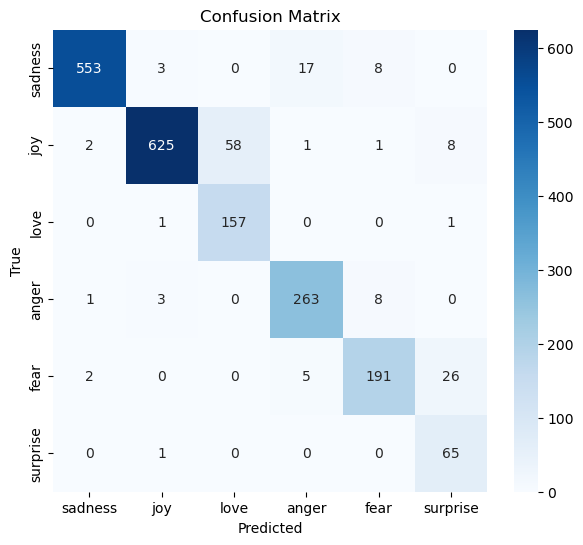

In [27]:
test_labels = df_test["label"].values
evaluate_on_test(model, test_encodings, test_labels)


### **Saving & load**

In [28]:
# Save model parameters
torch.save(model.state_dict(), "emotion_model.pt")

# Later: Load model
loaded_model = EmotionClassifier(num_classes=6, class_weights=list(class_weights))
loaded_model.load_state_dict(torch.load("emotion_model.pt"))
loaded_model.eval()


C:\Users\ZBook\AppData\Local\Temp\ipykernel_11528\1352544936.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("emotion_model.pt"))

EmotionClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Line

In [32]:
# Example prediction
loaded_model = EmotionClassifier(num_classes=6, class_weights=list(class_weights))
loaded_model.load_state_dict(torch.load("emotion_model.pt"))
loaded_model.eval()


tok = EmotionTokenizer()

prep = EmotionPreprocessor()


text = "i am now nearly finished the week detox and i feel amazing"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])


C:\Users\ZBook\AppData\Local\Temp\ipykernel_11528\268129923.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("emotion_model.pt"))


Predicted Emotion: surprise


In [29]:
# Example prediction
loaded_model = EmotionClassifier(num_classes=6, class_weights=list(class_weights),threshold=0.9)
loaded_model.load_state_dict(torch.load("emotion_model.pt"))
loaded_model.eval()


tok = EmotionTokenizer()

prep = EmotionPreprocessor()


text = "i am now nearly finished the week detox and i feel amazing"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])


C:\Users\ZBook\AppData\Local\Temp\ipykernel_21676\3813505372.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("emotion_model.pt"))

Predicted Emotion: surprise


In [30]:
text = "can you tell me more ?"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])

Predicted Emotion: normal


In [17]:
text = "i'am finished my work and i feel so relieved, but now i am so angry at my boss he didn't like my work, waht must i do"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])

Predicted Emotion: joy


In [34]:
text = "iam not sad"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])

Predicted Emotion: sadness


In [37]:
text = "open the door by your arm,and explain why"
clean_text = prep.clean_text(text)
encodings = tok.tokenize([clean_text])

prediction = loaded_model.predict(encodings["input_ids"], encodings["attention_mask"])
print("Predicted Emotion:", prediction[0])

Predicted Emotion: normal


<center>

# **Translation**

In [1]:
from transformers import MarianMTModel, MarianTokenizer

class Translator:
    def __init__(self, src_lang="ar", tgt_lang="en"):
        model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{tgt_lang}"
        self.tokenizer = MarianTokenizer.from_pretrained(model_name)
        self.model = MarianMTModel.from_pretrained(model_name)

    def translate(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True)
        translated = self.model.generate(**inputs)
        return [self.tokenizer.decode(t, skip_special_tokens=True) for t in translated][0]


In [2]:
translator = Translator(src_lang="ar", tgt_lang="en")
text = "في صباحٍ هادئ، خرجتُ للمشي على شاطئ البحر. كان الهواء منعشًا والأمواج تتحرك بهدوء. جلستُ لبعض الوقت أراقب الأفق وأستمتع بصوت البحر، ثم عدتُ إلى المنزل وأنا أشعر بالراحة والنشاط. 🌊☀️"
translated_text = translator.translate(text)
print("Translated:", translated_text)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

c:\Users\ZBook\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ZBook\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-ar-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


source.spm:   0%|          | 0.00/917k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

c:\Users\ZBook\anaconda3\Lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translated: In a quiet morning, I walked out on the seashore. The air was fresh and the waves were moving quietly. I sat down for a while, watching the horizon, enjoying the sound of the sea, and then I came home feeling comfortable and active.


In [3]:
translator = Translator(src_lang="ar", tgt_lang="en")
text = "في صباحٍ هادئ، خرجتُ للمشي على شاطئ البحر. كان الهواء منعشًا والأمواج تتحرك بهدوء. جلستُ لبعض الوقت أراقب الأفق وأستمتع بصوت البحر، ثم عدتُ إلى المنزل وأنا أشعر بالراحة والنشاط. 🌊☀️"
translated_text = translator.translate(text)
print("Translated:", translated_text)


Translated: In a quiet morning, I walked out on the seashore. The air was fresh and the waves were moving quietly. I sat down for a while, watching the horizon, enjoying the sound of the sea, and then I came home feeling comfortable and active.
